<img src="./Logo_UNSAM.png" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº4
#### Patricia González Todd

  El objetivo de este trabajo es caracterizar el desempeño estadístico de distintos estimadores de amplitud y frecuencia, analizando la relaciòn entre resoluciòn espectral y la exactitud en la medición de energía. Para evaluar este desempeño, nos enfocaremos en dos métricas fundamentales:El Sesgo ($s$): Que nos indica qué tan alejado está el valor esperado de nuestra estimación respecto al valor real (exactitud).La Varianza ($v$): Que mide la dispersión de las estimaciones ante diferentes realizaciones de ruido y variaciones de frecuencia (precisión).

Se simularán $R = 200$ **realizaciones** de una señal con frecuencia variable, modelada como:$$x(n) = a_0 \cdot \sin(\Omega_1 \cdot n) + n_a(n)$$Donde la frecuencia $\Omega_1$ fluctúa aleatoriamente alrededor de $\pi/2$ debido a una variable $f_r \sim U(-2, 2)$, lo que garantiza que la señal no sea siempre periódica respecto a la ventana de observación. Cada señal se pasará por distinttas ventanas, todas de $N = 1000$ **muestras** a una **frecuencia de muestreo**
$f_s = 1000$.
De este modo llenaremos una **matriz de NxR**.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import windows


def mi_funcion_ruido (N, Pr):
    desvio = np.sqrt(Pr)
    r = np.random.normal(0, desvio, N) # lo del medio es el desvio estandar
    #verifico el valor de la varianza de r a ver si calcule bien
    return r

    
# Parámetros
a0 = np.sqrt(2)
N = 1000
fs = 1000
deltaf = fs/N
W0 = np.pi/2
SNR_db = 10
Ps = (a0**2)/ 2
Pr = Ps / (10**(SNR_db/10))
R = 200

#genero las senoidales:

nn = np.arange (N)*(1/fs)
nn = nn.reshape(N,1)
matriz_n = np.tile(nn,(1,R))



fr = np.random.uniform(-2, 2, R)


f1 = (N/4 + fr) * deltaf


matriz_f = np.tile(f1, (N,1))



matriz_S = a0 * np.sin(2*np.pi* matriz_f *matriz_n) # esto es una matriz de N muestras por R de

r = mi_funcion_ruido(N, Pr)
r = r.reshape(N,1)
r = np.tile(r, (1,R))

matriz_Sr = matriz_S + r


Para cada ventana $w_i(n)$, definimos:
Estimador de Amplitud ($\hat{a}_1$): Evaluamos el módulo de la FFT en la frecuencia central teórica $\Omega_0 = \pi/2$.$$\hat{a}_{i} = \left| \mathcal{F}\{x(n) \cdot w_i(n)\} \right|_{\Omega_0}$$Estimador de Frecuencia ($\hat{\Omega}_1$): Identificamos la frecuencia donde se produce el máximo valor del espectro (método argmax).$$\hat{\Omega}_{i} = \arg \max_{f} \{ |X_{w_i}(\Omega)| \}$$2.3. Ventanas en EstudioAnalizaremos cuatro casos para observar el compromiso entre resolución espectral y exactitud en amplitud:Rectangular: Máxima resolución, pero muy sensible al leakage.Flat-top: Diseñada específicamente para minimizar el error de amplitud.Blackman-Harris: Excelente supresión de lóbulos secundarios.Hann: Una ventana de propósito general con buen balance.


Analizaremos cuatro tipos distintos de ventanas para observar el compromiso entre resolución espectral y exactitud en amplitud:

Rectangular: Máxima resolución, pero muy sensible al leakage.

Flat-top: Diseñada específicamente para minimizar el error de amplitud.

Blackman-Harris: Excelente supresión de lóbulos secundarios.

Hann: Una ventana de propósito general con buen balance.

C:\Users\Patog\AppData\Local\Temp\ipykernel_9792\3629586415.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


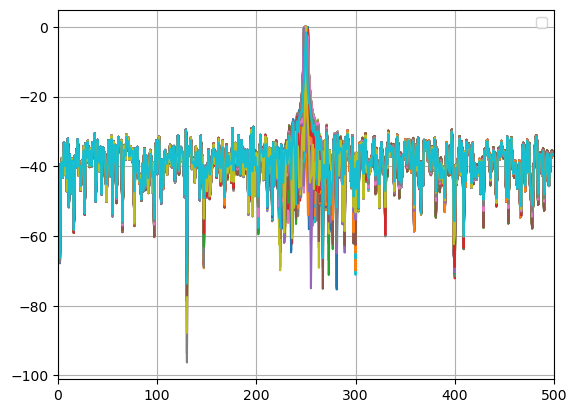

C:\Users\Patog\AppData\Local\Temp\ipykernel_9792\3629586415.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


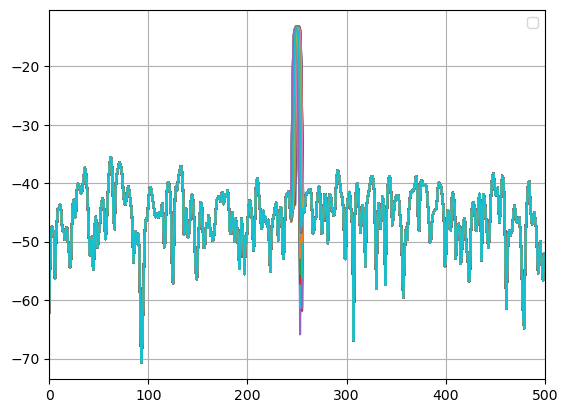

C:\Users\Patog\AppData\Local\Temp\ipykernel_9792\3629586415.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


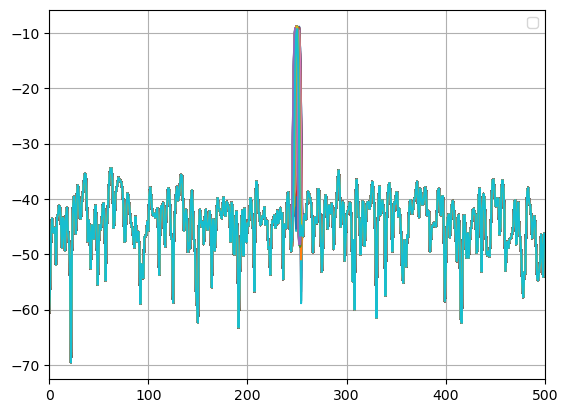

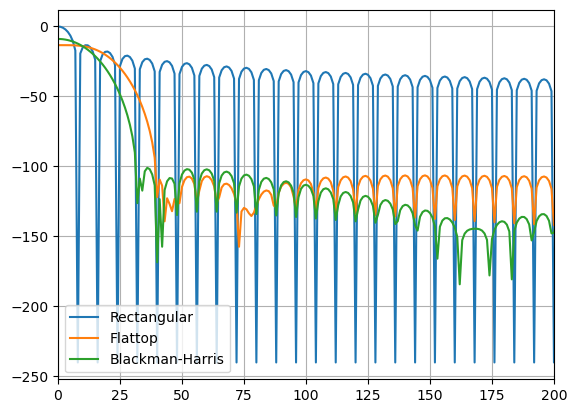

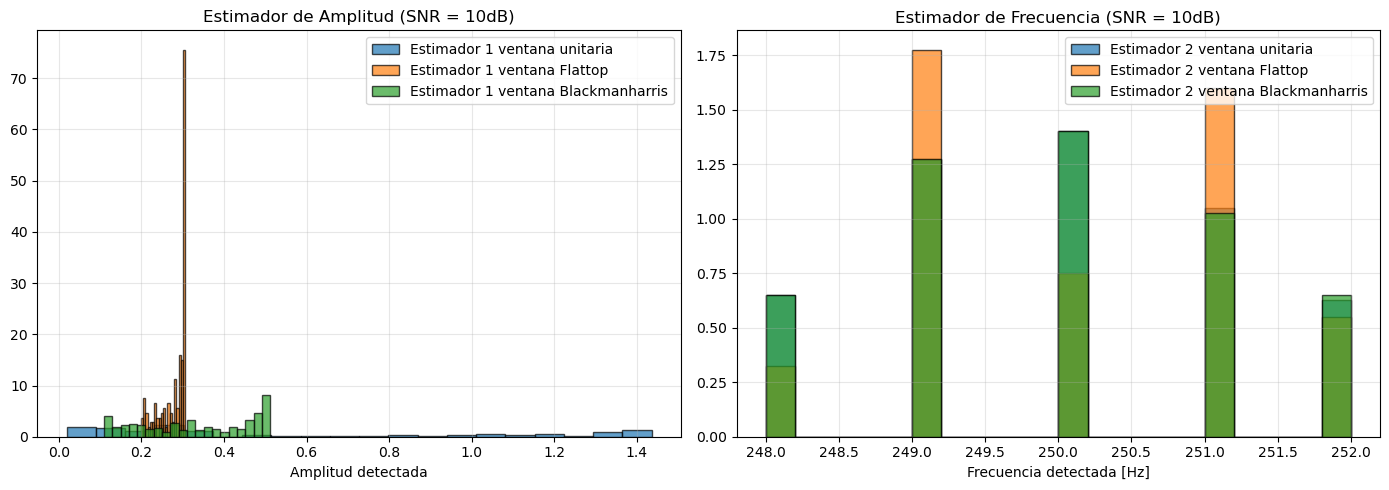

sumflat = 215.36294999899997
N = 1000
N/sumflat = 4.643324211544481
N/sumBmh = 358.3913100000001
N = 1000
N/sumBmh = 2.790246225557198
Ventana         | Sesgo Amp  | Var Amp    | Sesgo Freq | Var Freq  
---------------------------------------------------------------------------
Rectangular     |    -0.8652 |     0.2349 |    -0.0029 |     1.4820
Flat-top        |    -1.1356 |     0.0010 |     0.1071 |     1.3720
Blackman-H      |    -1.0782 |     0.0185 |     0.0021 |     1.4975


In [5]:
# %% SIN VENTANA

w1 = np.ones(N)
w1 = w1.reshape(N,1)
w1 = np.tile(w1, (1,R))

x1 = np.fft.fft(matriz_Sr,n=N,axis=0)/(N)  # normalizada con las muestras

mag_x1 = np.abs(x1[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x1 = (np.abs(x1)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x1_db = 10*np.log10(pot_x1[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf


plt.plot(pot_x1_db) 

plt.xlim(0, fs/2)
plt.legend()
plt.grid(0.01)
plt.show()
'''HASTA ACA SE QUE ESTOY ENTRE -2 Y 2'''


# %% VENTANA FLATTOP

w2 = windows.flattop(N)
w2 = w2.reshape(N,1)
w2 = np.tile(w2, (1,R))

x2 = np.fft.fft((matriz_Sr*w2),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x2 = np.abs(x2[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x2 = (np.abs(x2)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x2_db = 10*np.log10(pot_x2[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# Gráfico SOLO DEL DELTA
#plt.figure(figsize=(10, 10))
plt.plot(pot_x2_db) 

# línea vertical en x = 3

plt.xlim(0, fs/2)
plt.legend()
plt.grid(0.01)
plt.show()
'''HASTA ACA SE QUE ESTOY ENTRE -2 Y 2'''



# %% VENTANA Blackmanharris

w3 = windows.blackmanharris(N)
w3 = w3.reshape(N,1)
w3 = np.tile(w3, (1,R))

x3 = np.fft.fft((matriz_Sr*w3),n=N,axis=0)/(N)  # normalizada con las muestras

mag_x3 = np.abs(x3[:N//2, :]) * 2 # Espectro unilateral corregido

#n y axis lo que hacen es decirle en que direccion y como es cada grupo que quiero analizar
pot_x3 = (np.abs(x3)**2)*2 
#me queda el espectro de un solo lado porque antes se distribuia 1/2 a cada lado

# paso a db
pot_x3_db = 10*np.log10(pot_x3[:N//2] + 1e-12) #db

ffreq = np.arange(0, N)*deltaf

# Gráfico SOLO DEL DELTA
#plt.figure(figsize=(10, 10))
plt.plot(pot_x3_db) 

# línea vertical en x = 3

plt.xlim(0, fs/2)
plt.legend()
plt.grid(0.01)
plt.show()
'''HASTA ACA SE QUE ESTOY ENTRE -2 Y 2'''

# %%
W1 = np.fft.fft(np.ones(N), n=N*8)
W2 = np.fft.fft(windows.flattop(N), n=N*8)
W3 = np.fft.fft(windows.blackmanharris(N), n=N*8)

W1_db = 20*np.log10(np.abs(W1)/N + 1e-12)
W2_db = 20*np.log10(np.abs(W2)/N + 1e-12)
W3_db = 20*np.log10(np.abs(W3)/N + 1e-12)

plt.plot(W1_db, label='Rectangular')
plt.plot(W2_db, label='Flattop')
plt.plot(W3_db, label='Blackman-Harris')
plt.xlim(0, 200)
plt.legend()
plt.grid()
plt.show()


# %% Estimadores

#para mi primer estimador lo que quiero es ver que hay en la feta de omega 0
a1_x1 = mag_x1[int(N/4), :]
a1_x2 = mag_x2[int(N/4), :]
a1_x3 = mag_x3[int(N/4), :]

#quiero llegar a una matriz de rx4 de ahi hago el histograma, ese 4 son las 4 ventanas que quiero probar

'''
SEGUNDO ESTIMADOR -> AHORA TRABAJO EL ARGUMENTO
quiero quedarme con los maximos, osea todos los argumosntos N/4
aca llo que quiero es ver todos los maximos
hay lit una funcion que es argmax  y ese va a ser mi estimador (omega sombrerito),
 luego el sesgo es omega sombrerito menos omega
 quiero detectar esos maximos y por si acaso verificar que  esten bien
'''
sigma1_x1 = np.argmax(mag_x1, axis = 0)*deltaf
sigma1_x2 = np.argmax(mag_x2 , axis = 0)*deltaf
sigma1_x3 = np.argmax(mag_x3 , axis = 0)*deltaf

Mu_a = np.mean(x1)

sesgo = Mu_a - a0

#%% Hitogramas

fig, (Ha, Hf) = plt.subplots(1, 2, figsize=(14, 5))

# amplitud 
Ha.hist(a1_x1, bins=20, density=True, alpha=0.7, edgecolor='black', label = "Estimador 1 ventana unitaria")
Ha.hist(a1_x2, bins=20, density=True, alpha=0.7, edgecolor='black', label = "Estimador 1 ventana Flattop")
Ha.hist(a1_x3 , bins=20, density=True, alpha=0.7, edgecolor='black', label = "Estimador 1 ventana Blackmanharris")

Ha.set_title(f'Estimador de Amplitud (SNR = {SNR_db}dB)')
Ha.set_xlabel('Amplitud detectada')
Ha.legend()
Ha.grid(alpha=0.3)

# Hitograma freq 
Hf.hist(sigma1_x1 , bins=20, density=True, alpha=0.7, edgecolor='black', label = "Estimador 2 ventana unitaria")
Hf.hist(sigma1_x2 , bins=20, density=True, alpha=0.7, edgecolor='black', label = "Estimador 2 ventana Flattop")
Hf.hist(sigma1_x3 , bins=20, density=True, alpha=0.7, edgecolor='black', label = "Estimador 2 ventana Blackmanharris")

Hf.set_title(f'Estimador de Frecuencia (SNR = {SNR_db}dB)')
Hf.set_xlabel('Frecuencia detectada [Hz]')
Hf.legend()
Hf.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# %% ANALISIS

print(f"sumflat = {(np.sum(windows.flattop(N)))}")   
print(f"N = {N}") 
print(f"N/sumflat = {N/(np.sum(windows.flattop(N)))}")

print(f"N/sumBmh = {(np.sum(windows.blackmanharris(N)))}")   
print(f"N = {N}")
print(f"N/sumBmh = {N/(np.sum(windows.blackmanharris(N)))}")

# --- SESGOS Y VARIANZAS ---

# 1. Rectangular
# El estimador de amplitud (a1_x1) ya lo sacaste de mag_x1[int(N/4), :]
var_a1_x1 = np.var(a1_x1)
var_s1_x1 = np.var(sigma1_x1)
sesgo_a1_x1 = np.mean(a1_x1) - a0
sesgo_s1_x1 = np.mean(sigma1_x1 - f1)

# 2. Flat-top
# Usamos el estimador a1_x2 que extrajiste de mag_x2
var_a1_x2 = np.var(a1_x2)
var_s1_x2 = np.var(sigma1_x2)
sesgo_a1_x2 = np.mean(a1_x2) - a0
sesgo_s1_x2 = np.mean(sigma1_x2 -f1)

# 3. Blackman-Harris
# Usamos el estimador a1_x3 que extrajiste de mag_x3
var_a1_x3 = np.var(a1_x3)
var_s1_x3 = np.var(sigma1_x3)
sesgo_a1_x3 = np.mean(a1_x3) - a0
sesgo_s1_x3 = np.mean(sigma1_x3 - f1)

# Estructura para la tabla
resultados = [
    ["Rectangular", sesgo_a1_x1, var_a1_x1, sesgo_s1_x1, var_s1_x1],
    ["Flat-top",    sesgo_a1_x2, var_a1_x2, sesgo_s1_x2, var_s1_x2],
    ["Blackman-H",  sesgo_a1_x3, var_a1_x3, sesgo_s1_x3, var_s1_x3]
]

print(f"{'Ventana':<15} | {'Sesgo Amp':<10} | {'Var Amp':<10} | {'Sesgo Freq':<10} | {'Var Freq':<10}")
print("-" * 75)
for r in resultados:
    print(f"{r[0]:<15} | {r[1]:10.4f} | {r[2]:10.4f} | {r[3]:10.4f} | {r[4]:10.4f}")


#### 4. Análisis de Resultados: Sesgo y Varianza
   Al observar la tabla y los histogramas obtenidos, se pueden extraer conclusiones fundamentales sobre el comportamiento de cada ventana:
   
##### 4.1. Estimadores de Amplitud: 
Notamos que todas las ventanas presentan un sesgo significativo respecto al valor real $a_0 = \sqrt{2} \approx 1.41$.En la ventana Rectangular, el sesgo negativo es producto del Spectral Leakage : al no coincidir la frecuencia de la señal con un bin exacto de la FFT, la energía "se escapa" hacia los lados.En las ventanas Flat-top y Blackman-Harris, el sesgo es aún mayor debido a que no hemos compensado la Ganancia Coherente (la suma de los valores de la ventana). 
    
Sin embargo, la falta de normalización nos permite visualizar claramente cómo cada ventana escala la señal de forma distinta. Esto permiite interpretar las diferencias de varianza, mientras la ventana rectangular distribuye las amplitudes entre cero y raiz de dos de una forma bastante uniforme,la ventana Flat-top presenta una dispersión mucho menor (una campana más angosta en el histograma), lo que indica que es más robusta frente a las variaciones de frecuencia ($f_r$) y la Blackmanharris se encuentra en un punto medio entre ambas.
   
   ##### 4.2. Estimadores de Frecuencia:
   El sesgo de frecuencia tiende a ser bajo en todos los casos, ya que el máximo del lóbulo principal sigue centrado en la frecuencia de la señal. No obstante, la varianza está limitada por la resolución del bin ($\Delta f = 1$ Hz). Para mejorar la precisión de este estimador, sería necesario recurrir a técnicas como el Zero-Padding.5. Normalización y Corrección de EstimadoresPara realizar una comparación justa de la precisión de los estimadores, debemos eliminar el sesgo sistemático provocado por la morfología de cada ventana. Para ello, procederemos a normalizar los resultados dividiendo cada estimación por su respectiva Ganancia Coherente (CG):$$CG = \frac{1}{N} \sum_{n=0}^{N-1} w(n)$$Al aplicar esta corrección, los histogramas deberían alinearse sobre el valor real $a_0$, permitiéndonos comparar puramente qué ventana es menos sensible al ruido y al desplazamiento de frecuencia.